## Airbnb (Data Cleaning)

This project is a general purpose data cleaning project.

#### Importing necessary libraries

In [1]:
import numpy as np
import pandas as pd
pd.set_option("display.max_columns", None)
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import re

#### Importing the dataset

In [ ]:
data = pd.read_csv("A:\Data cleaning\airbnb-data-cleaning\data\raw\Airbnb_Open_Data.csv")

#### Exploratory data analysis

In [6]:
data.head()

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,country code,instant_bookable,cancellation_policy,room type,Construction year,price,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,US,False,strict,Private room,2020.0,$966,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,US,False,moderate,Entire home/apt,2007.0,$142,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,US,True,flexible,Private room,2005.0,$620,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,US,True,moderate,Entire home/apt,2005.0,$368,$74,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,US,False,moderate,Entire home/apt,2009.0,$204,$41,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


In [7]:
data.shape

(102599, 26)

In [8]:
data.columns

Index(['id', 'NAME', 'host id', 'host_identity_verified', 'host name',
       'neighbourhood group', 'neighbourhood', 'lat', 'long', 'country',
       'country code', 'instant_bookable', 'cancellation_policy', 'room type',
       'Construction year', 'price', 'service fee', 'minimum nights',
       'number of reviews', 'last review', 'reviews per month',
       'review rate number', 'calculated host listings count',
       'availability 365', 'house_rules', 'license'],
      dtype='object')

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              102599 non-null  int64  
 1   NAME                            102349 non-null  object 
 2   host id                         102599 non-null  int64  
 3   host_identity_verified          102310 non-null  object 
 4   host name                       102193 non-null  object 
 5   neighbourhood group             102570 non-null  object 
 6   neighbourhood                   102583 non-null  object 
 7   lat                             102591 non-null  float64
 8   long                            102591 non-null  float64
 9   country                         102067 non-null  object 
 10  country code                    102468 non-null  object 
 11  instant_bookable                102494 non-null  object 
 12  cancellation_pol

In [10]:
pd.options.display.float_format = '{:,.2f}'.format
data.describe()
pd.reset_option('display.float_format')

In [11]:
data.describe(include= "object")

,NAME,host_identity_verified,host name,neighbourhood group,neighbourhood,country,country code,instant_bookable,cancellation_policy,room type,price,service fee,last review,house_rules,license
count,102349,102310,102193,102570,102583,102067,102468,102494,102523,102599,102352,102326,86706,50468,2
unique,61281,2,13190,7,224,1,1,2,3,4,1151,231,2477,1976,1
top,Home away from home,unconfirmed,Michael,Manhattan,Bedford-Stuyvesant,United States,US,False,moderate,Entire home/apt,$206,$41,6/23/2019,#NAME?,41662/AL
freq,33,51200,881,43792,7937,102067,102468,51474,34343,53701,137,526,2443,2712,2


In [12]:
data.isnull().sum()

id                                     0
NAME                                 250
host id                                0
host_identity_verified               289
host name                            406
neighbourhood group                   29
neighbourhood                         16
lat                                    8
long                                   8
country                              532
country code                         131
instant_bookable                     105
cancellation_policy                   76
room type                              0
Construction year                    214
price                                247
service fee                          273
minimum nights                       409
number of reviews                    183
last review                        15893
reviews per month                  15879
review rate number                   326
calculated host listings count       319
availability 365                     448
house_rules     

In [13]:
for col in data.columns:
    if data[col].nunique() < 40:
        print(data[col].value_counts())
        print("-"*40)

host_identity_verified
unconfirmed    51200
verified       51110
Name: count, dtype: int64
----------------------------------------
neighbourhood group
Manhattan        43792
Brooklyn         41842
Queens           13267
Bronx             2712
Staten Island      955
brookln              1
manhatan             1
Name: count, dtype: int64
----------------------------------------
country
United States    102067
Name: count, dtype: int64
----------------------------------------
country code
US    102468
Name: count, dtype: int64
----------------------------------------
instant_bookable
False    51474
True     51020
Name: count, dtype: int64
----------------------------------------
cancellation_policy
moderate    34343
strict      34106
flexible    34074
Name: count, dtype: int64
----------------------------------------
room type
Entire home/apt    53701
Private room       46556
Shared room         2226
Hotel room           116
Name: count, dtype: int64
-------------------------------------

#### Dropping unnecesarry/not suitable to work with columns

In [14]:
columns_to_keep = ['NAME', 'host id', 'host_identity_verified', 'host name',
       'neighbourhood group', 'neighbourhood', 'lat', 'long', 'country',
       'country code', 'instant_bookable', 'cancellation_policy', 'room type',
       'Construction year', 'price', 'service fee', 'minimum nights',
       'number of reviews', 'last review']

columns_to_drop = ['reviews per month',
       'review rate number', 'calculated host listings count',
       'availability 365', 'house_rules', 'license', 'id']

print(f"Columns to keep: {len(columns_to_keep)}\nColumns to drop: {len(columns_to_drop)}")

Columns to keep: 19
Columns to drop: 7


#### Working with new data

In [15]:
df = data[columns_to_keep]

In [16]:
df

,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,country code,instant_bookable,cancellation_policy,room type,Construction year,price,service fee,minimum nights,number of reviews,last review
0,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,US,False,strict,Private room,2020.0,$966,$193,10.0,9.0,10/19/2021
1,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,US,False,moderate,Entire home/apt,2007.0,$142,$28,30.0,45.0,5/21/2022
2,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,US,True,flexible,Private room,2005.0,$620,$124,3.0,0.0,NaN
3,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,US,True,moderate,Entire home/apt,2005.0,$368,$74,30.0,270.0,7/5/2019
4,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,US,False,moderate,Entire home/apt,2009.0,$204,$41,10.0,9.0,11/19/2018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102594,Spare room in Williamsburg,12312296767,verified,Krik,Brooklyn,Williamsburg,40.70862,-73.94651,United States,US,False,flexible,Private room,2003.0,$844,$169,1.0,0.0,NaN
102595,Best Location near Columbia U,77864383453,unconfirmed,Mifan,Manhattan,Morningside Heights,40.80460,-73.96545,United States,US,True,moderate,Private room,2016.0,$837,$167,1.0,1.0,7/6/2015
102596,"Comfy, bright room in Brooklyn",69050334417,unconfirmed,Megan,Brooklyn,Park Slope,40.67505,-73.98045,United States,US,True,moderate,Private room,2009.0,$988,$198,3.0,0.0,NaN
102597,Big Studio-One Stop from Midtown,11160591270,unconfirmed,Christopher,Queens,Long Island City,40.74989,-73.93777,United States,US,True,strict,Entire home/apt,2015.0,$546,$109,2.0,5.0,10/11/2015


#### Dropping unnecessary columns

In [17]:
rename_columns = ["Name", "Host ID", "Host identity verified", "Host name", "Neighbourhood group", "Neighbourhood", "Lat", "Long", "Country", "Country code",
                  "Instant bookable", "Cancellation policy", "Room type", "Construction year", "Price", "Service fee", "Minimum nights", "Number of reviews", "Last review"]

for i, j in zip(df.columns, rename_columns):
    df.rename(columns= {i: j}, inplace= True)

df.columns

Index(['Name', 'Host ID', 'Host identity verified', 'Host name',
       'Neighbourhood group', 'Neighbourhood', 'Lat', 'Long', 'Country',
       'Country code', 'Instant bookable', 'Cancellation policy', 'Room type',
       'Construction year', 'Price', 'Service fee', 'Minimum nights',
       'Number of reviews', 'Last review'],
      dtype='object')

#### Fixing naming errors

In [18]:
correct = {
    "manhatan": "Manhattan",
    "brookln": "Brooklyn"
}

df["Neighbourhood group"] = df["Neighbourhood group"].replace(correct)

#### Dropping what's not needed

In [19]:
df.duplicated().sum()

np.int64(541)

In [20]:
df.drop_duplicates(inplace= True)
df.duplicated().sum()

np.int64(0)

In [21]:
df.shape

(102058, 19)

In [22]:
df.isna().sum()

Name                        250
Host ID                       0
Host identity verified      289
Host name                   404
Neighbourhood group          29
Neighbourhood                16
Lat                           8
Long                          8
Country                     532
Country code                131
Instant bookable            105
Cancellation policy          76
Room type                     0
Construction year           214
Price                       247
Service fee                 273
Minimum nights              400
Number of reviews           183
Last review               15832
dtype: int64

In [23]:
df.drop(columns= "Last review", inplace= True)

In [24]:
df.isna().sum()

Name                      250
Host ID                     0
Host identity verified    289
Host name                 404
Neighbourhood group        29
Neighbourhood              16
Lat                         8
Long                        8
Country                   532
Country code              131
Instant bookable          105
Cancellation policy        76
Room type                   0
Construction year         214
Price                     247
Service fee               273
Minimum nights            400
Number of reviews         183
dtype: int64

In [25]:
df.dropna(inplace= True)
df.shape

(99342, 18)

#### Fixing datatypes

In [26]:
df.head()

,Name,Host ID,Host identity verified,Host name,Neighbourhood group,Neighbourhood,Lat,Long,Country,Country code,Instant bookable,Cancellation policy,Room type,Construction year,Price,Service fee,Minimum nights,Number of reviews
0,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,US,False,strict,Private room,2020.0,$966,$193,10.0,9.0
1,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,US,False,moderate,Entire home/apt,2007.0,$142,$28,30.0,45.0
4,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,US,False,moderate,Entire home/apt,2009.0,$204,$41,10.0,9.0
5,Large Cozy 1 BR Apartment In Midtown East,45498551794,verified,Michelle,Manhattan,Murray Hill,40.74767,-73.97500,United States,US,True,flexible,Entire home/apt,2013.0,$577,$115,3.0,74.0
7,BlissArtsSpace!,90821839709,unconfirmed,Emma,Brooklyn,Bedford-Stuyvesant,40.68688,-73.95596,United States,US,False,moderate,Private room,2009.0,"$1,060",$212,45.0,49.0


In [27]:
df["Construction year"].value_counts()

Construction year
2014.0    5085
2006.0    5071
2008.0    5056
2019.0    5047
2010.0    5030
2009.0    5015
2020.0    5001
2005.0    4986
2012.0    4983
2022.0    4979
2003.0    4954
2007.0    4953
2015.0    4952
2011.0    4913
2017.0    4912
2021.0    4899
2013.0    4891
2018.0    4882
2004.0    4869
2016.0    4864
Name: count, dtype: int64

In [28]:
df["Construction year"] = df["Construction year"].astype("int64")

In [29]:
df["Price"] = df["Price"].str.replace("$","", regex= False)
df["Price"] = df["Price"].str.replace(",", "", regex= False).astype(int)

df["Service fee"] = df["Service fee"].str.replace("$","", regex= False)
df["Service fee"] = df["Service fee"].str.replace(",", "", regex= False).astype(int)

df["Minimum nights"] = df["Minimum nights"].astype(int)
df["Number of reviews"] = df["Number of reviews"].astype(int)

#### Visualizing the data & making final changes

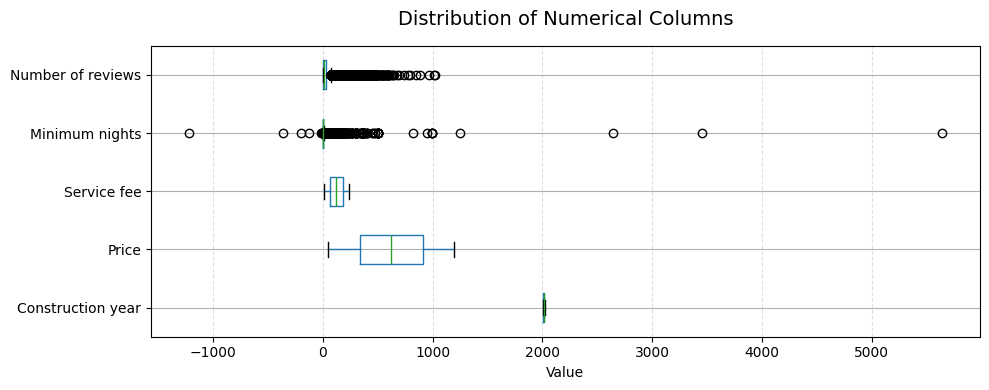

In [30]:
numerical_cols = ['Construction year', 'Price', 'Service fee', 'Minimum nights',
       'Number of reviews']

cols = [c for c in numerical_cols if c in df.columns]

fig, ax = plt.subplots(figsize=(10, max(4, len(cols) * 0.6)))

df[cols].boxplot(
    vert=False,
    ax=ax,
    showfliers=True
)

ax.set_title("Distribution of Numerical Columns", fontsize=14, pad=15)
ax.set_xlabel("Value")
ax.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [31]:
print(df["Minimum nights"].describe())

print(df["Minimum nights"].quantile([
    0.90, 0.95, 0.99, 0.995
]))

count    99342.000000
mean         8.071229
std         30.412617
min      -1223.000000
25%          2.000000
50%          3.000000
75%          5.000000
max       5645.000000
Name: Minimum nights, dtype: float64
0.900    30.0
0.950    30.0
0.990    50.0
0.995    90.0
Name: Minimum nights, dtype: float64


In [32]:
df.loc[df["Minimum nights"] < 0, "Minimum nights"] = np.nan
df.dropna(inplace= True)

#### Exporting the dataset

In [ ]:
def clean_illegal_chars(val):
    if isinstance(val, str):
        return re.sub(r'[\x00-\x1F\x7F-\x9F]', '', val)
    return val

df = df.map(clean_illegal_chars)

import sys
!{sys.executable} -m pip install XlsxWriter

import xlsxwriter
print(xlsxwriter.__version__)

df_copy = df.copy()
df_copy.to_excel("A:\Data cleaning\airbnb-data-cleaning\data\cleaned\Airbnb_cleaned.xlsx", index= False, engine= "xlsxwriter")

3.2.9



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Validating the dataset

#### Importing the cleaned dataset

In [2]:
df_clean = pd.read_excel(r"A:\Data cleaning\airbnb-data-cleaning\data\cleaned\Airbnb_cleaned.xlsx")

df_clean.head()

,Name,Host ID,Host identity verified,Host name,Neighbourhood group,Neighbourhood,Lat,Long,Country,Country code,Instant bookable,Cancellation policy,Room type,Construction year,Price,Service fee,Minimum nights,Number of reviews
0,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,US,False,strict,Private room,2020,966,193,10,9
1,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,US,False,moderate,Entire home/apt,2007,142,28,30,45
2,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,US,False,moderate,Entire home/apt,2009,204,41,10,9
3,Large Cozy 1 BR Apartment In Midtown East,45498551794,verified,Michelle,Manhattan,Murray Hill,40.74767,-73.97500,United States,US,True,flexible,Entire home/apt,2013,577,115,3,74
4,BlissArtsSpace!,90821839709,unconfirmed,Emma,Brooklyn,Bedford-Stuyvesant,40.68688,-73.95596,United States,US,False,moderate,Private room,2009,1060,212,45,49


#### Exploratory data analysis

In [3]:
df_clean.shape

(99330, 18)

In [4]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99330 entries, 0 to 99329
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Name                    99330 non-null  object 
 1   Host ID                 99330 non-null  int64  
 2   Host identity verified  99330 non-null  object 
 3   Host name               99330 non-null  object 
 4   Neighbourhood group     99330 non-null  object 
 5   Neighbourhood           99330 non-null  object 
 6   Lat                     99330 non-null  float64
 7   Long                    99330 non-null  float64
 8   Country                 99330 non-null  object 
 9   Country code            99330 non-null  object 
 10  Instant bookable        99330 non-null  bool   
 11  Cancellation policy     99330 non-null  object 
 12  Room type               99330 non-null  object 
 13  Construction year       99330 non-null  int64  
 14  Price                   99330 non-null

In [5]:
df_clean.isnull().sum()

Name                      0
Host ID                   0
Host identity verified    0
Host name                 0
Neighbourhood group       0
Neighbourhood             0
Lat                       0
Long                      0
Country                   0
Country code              0
Instant bookable          0
Cancellation policy       0
Room type                 0
Construction year         0
Price                     0
Service fee               0
Minimum nights            0
Number of reviews         0
dtype: int64

In [8]:
for col in df_clean.columns:
    if df_clean[col].nunique() < 40:
        print(df_clean[col].value_counts())
        print("-"*40)

Host identity verified
unconfirmed    49703
verified       49627
Name: count, dtype: int64
----------------------------------------
Neighbourhood group
Manhattan        42391
Brooklyn         40525
Queens           12867
Bronx             2627
Staten Island      920
Name: count, dtype: int64
----------------------------------------
Country
United States    99330
Name: count, dtype: int64
----------------------------------------
Country code
US    99330
Name: count, dtype: int64
----------------------------------------
Instant bookable
False    49870
True     49460
Name: count, dtype: int64
----------------------------------------
Cancellation policy
moderate    33269
strict      33074
flexible    32987
Name: count, dtype: int64
----------------------------------------
Room type
Entire home/apt    52047
Private room       45018
Shared room         2157
Hotel room           108
Name: count, dtype: int64
----------------------------------------
Construction year
2014    5084
2006    5071


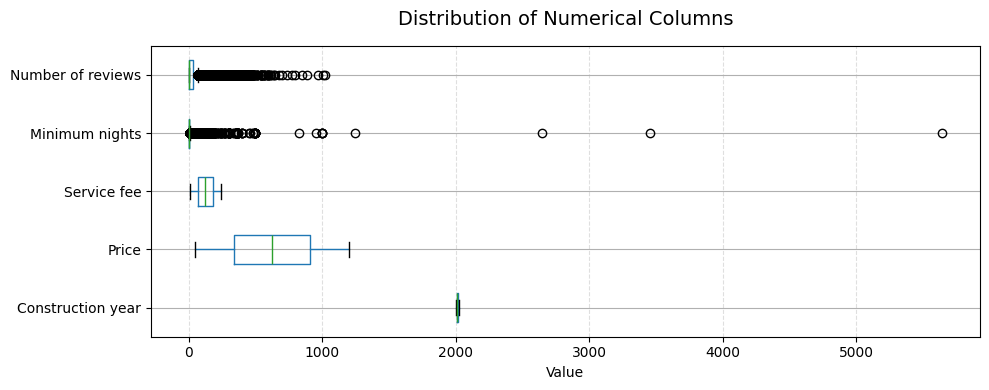

In [9]:
numerical_cols = ['Construction year', 'Price', 'Service fee', 'Minimum nights',
       'Number of reviews']

cols = [c for c in numerical_cols if c in df_clean.columns]

fig, ax = plt.subplots(figsize=(10, max(4, len(cols) * 0.6)))

df_clean[cols].boxplot(
    vert=False,
    ax=ax,
    showfliers=True
)

ax.set_title("Distribution of Numerical Columns", fontsize=14, pad=15)
ax.set_xlabel("Value")
ax.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [10]:
df_clean.duplicated().value_counts()

False    99330
Name: count, dtype: int64